# DICOR Mechanical Phenotypes Analysis

## Aim

To identify latent mechanical phenotypes of the left ventricle based on DICOR variability metrics and evaluate their association with false tendon architecture.

## Main hypothesis

False tendons may not directly determine a single mechanical parameter, but may be associated with distinct patterns of myocardial heterogeneity and mechanical dispersion.

## Analytical strategy

1. Select DICOR variability features.
2. Standardize features using Z-score normalization.
3. Perform unsupervised clustering.
4. Define mechanical phenotypes.
5. Test association between phenotypes and:
   - Chord_Orientation
   - Chord_Spread_Class
   - Chord_Topology_Class

## Statistical philosophy

This analysis is exploratory and hypothesis-generating rather than confirmatory.
Due to moderate sample size (n≈66), emphasis is placed on:
- effect sizes,
- phenotype interpretability,
- robustness of clustering structure,
rather than solely on p-values.


In [2]:
# ==========================================
# Imports
# ==========================================

from pathlib import Path

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# ==========================================
# Paths
# ==========================================

PROJECT_ROOT = Path(r"C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords")

DATA_PATH = PROJECT_ROOT / "data" / "final_analysis_dataset_ver2.xlsx"

OUTPUT_DIR = PROJECT_ROOT / "output"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR = OUTPUT_DIR / "tables"
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"

for path in [OUTPUT_DIR, FIGURES_DIR, TABLES_DIR, INTERIM_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("Data path:", DATA_PATH)
print("File exists:", DATA_PATH.exists())

# ==========================================
# Load dataset
# ==========================================

df = pd.read_excel(DATA_PATH)

print("Dataset shape:", df.shape)
display(df.head())

# ==========================================
# DICOR cohort selection
# ==========================================

dicor_vars = [
    "dicor_ssou_cv_pct",
    "dicor_sm_kdtr_cv_pct"
]

architecture_vars = [
    "Chord_Orientation",
    "Chord_Spread_Class",
    "Chord_Topology_Class"
]

required_cols = dicor_vars + architecture_vars

missing_cols = [col for col in required_cols if col not in df.columns]

if missing_cols:
    raise ValueError(f"Missing columns: {missing_cols}")

dicor_df = df[required_cols].copy()

# Drop missing DICOR rows only
dicor_df = dicor_df.dropna(subset=dicor_vars)

print("DICOR cohort shape:", dicor_df.shape)

# ==========================================
# Feature matrix
# ==========================================

X = dicor_df[dicor_vars].copy()

print("\nRaw feature summary:")
display(X.describe().T)

# ==========================================
# Z-standardization
# ==========================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(
    X_scaled,
    columns=[f"{col}_z" for col in dicor_vars],
    index=X.index
)

dicor_work = pd.concat([dicor_df, X_scaled], axis=1)

print("\nScaled feature summary:")
display(X_scaled.describe().T.round(3))

display(dicor_work.head())

# Save interim file
OUT_PATH = INTERIM_DIR / "dicor_mechanical_phenotypes_working_dataset.xlsx"
dicor_work.to_excel(OUT_PATH, index=False)

print("Saved:", OUT_PATH)

Data path: C:\Users\Ars\projects\university\lab_urfu_2026\false-lv-chords\data\final_analysis_dataset_ver2.xlsx
File exists: True
Dataset shape: (153, 214)


,subject_full_name,age,height_cm,weight_cm,BSA,sex,IMT,echo_ascending_aorta_diameter_mm_div_bsa,echo_ascending_aorta_diameter_mm,echo_aortic_sinus_diameter_mm_div_bsa,...,strain_plus_mid_inferior_chord_attachment_flag,strain_plus_mid_inferoseptal_chord_attachment_flag,strain_plus_apical_anteroseptal_chord_attachment_flag,strain_plus_apical_anterior_chord_attachment_flag,strain_plus_apical_anterolateral_chord_attachment_flag,strain_plus_apical_inferolateral_chord_attachment_flag,strain_plus_apical_inferior_chord_attachment_flag,strain_plus_apical_inferoseptal_chord_attachment_flag,echo_lv_strain_plus_cv_pct,echo_lv_strain_rate_cv_pct
0,Абатурова,23.0,176.0,70.0,1.849925,1.0,23.0,14.054624,26.0,13.514062,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Абросимова,15.0,163.0,62.0,1.675477,1.0,23.3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Айтиева,20.0,155.0,58.5,1.587057,1.0,24.5,16.382524,26.0,16.382524,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Алиева,21.0,152.0,53.3,1.500148,1.0,23.0,17.331622,26.0,15.331819,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Артемова,17.0,161.0,55.0,1.568350,1.0,21.0,13.389867,21.0,13.389867,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


ValueError: Missing columns: ['Chord_Orientation', 'Chord_Spread_Class', 'Chord_Topology_Class']

In [3]:
# Поиск колонок, похожих на нужные классификации

keywords = [
    "orientation", "spread", "topology",
    "chord", "tendon", "class"
]

matched_cols = []

for col in df.columns:
    col_lower = col.lower()
    if any(k in col_lower for k in keywords):
        matched_cols.append(col)

print("Matched columns:", len(matched_cols))

for col in matched_cols:
    print(col)

Matched columns: 49
lv_false_tendon_apical_oblique_count
lv_false_tendon_apical_transverse_count
lv_false_tendon_mid_oblique_count
lv_false_tendon_mid_transverse_count
lv_false_tendon_mid_and_basal_transverse_count
lv_false_tendon_basal_oblique_count
lv_false_tendon_basal_transverse_count
lv_false_tendon_mid_to_basal_oblique_count
lv_false_tendon_mid_to_apical_oblique_count
lv_false_tendon_basal_to_apical_oblique_count
lv_false_tendon_total_count
lv_false_tendon_pattern_sbza_count
lv_false_tendon_pattern_sbla_count
lv_false_tendon_pattern_ssz_count
lv_false_tendon_pattern_ssl_count
lv_false_tendon_pattern_ssza_count
lv_false_tendon_pattern_ssla_count
lv_false_tendon_pattern_sbzs_count
lv_false_tendon_pattern_sbls_count
lv_false_tendon_pattern_pb_count
lv_false_tendon_anterior_count
significant_lv_false_tendon_without_anterior_count
lv_false_tendon_posterior_count
significant_lv_false_tendon_without_posterior_count
lv_false_tendon_lateral_count
significant_lv_false_tendon_without_latera

In [6]:
# ==========================================
# Orientation phenotype
# ==========================================

oblique_cols = [
    "lv_false_tendon_apical_oblique_count",
    "lv_false_tendon_mid_oblique_count",
    "lv_false_tendon_basal_oblique_count",
    "lv_false_tendon_mid_to_basal_oblique_count",
    "lv_false_tendon_mid_to_apical_oblique_count",
    "lv_false_tendon_basal_to_apical_oblique_count",
]

transverse_cols = [
    "lv_false_tendon_apical_transverse_count",
    "lv_false_tendon_mid_transverse_count",
    "lv_false_tendon_mid_and_basal_transverse_count",
    "lv_false_tendon_basal_transverse_count",
]

# Fill NA as 0
for col in oblique_cols + transverse_cols:
    if col not in df.columns:
        raise ValueError(f"Missing column: {col}")
    
    df[col] = df[col].fillna(0)

# Counts
df["oblique_total"] = df[oblique_cols].sum(axis=1)
df["transverse_total"] = df[transverse_cols].sum(axis=1)

# Orientation phenotype
df["Chord_Orientation"] = np.select(
    [
        (df["transverse_total"] > 0),
        (df["transverse_total"] == 0) & (df["oblique_total"] > 0),
    ],
    [
        "Transverse-Involved",
        "Oblique-Only",
    ],
    default="Unclassified"
)

print(df["Chord_Orientation"].value_counts(dropna=False))

display(
    df[
        [
            "oblique_total",
            "transverse_total",
            "Chord_Orientation"
        ]
    ].head(15)
)

Chord_Orientation
Transverse-Involved    83
Unclassified           55
Oblique-Only           15
Name: count, dtype: int64


,oblique_total,transverse_total,Chord_Orientation
0,4.0,1.0,Transverse-Involved
1,0.0,0.0,Unclassified
2,2.0,5.0,Transverse-Involved
3,1.0,6.0,Transverse-Involved
4,0.0,0.0,Unclassified
5,1.0,7.0,Transverse-Involved
6,0.0,5.0,Transverse-Involved
7,2.0,1.0,Transverse-Involved
8,1.0,7.0,Transverse-Involved
9,0.0,0.0,Unclassified


In [7]:
# ==========================================
# Spatial Spread phenotype
# ==========================================

zone_cols = {
    "apical": [
        "lv_false_tendon_apical_oblique_count",
        "lv_false_tendon_apical_transverse_count",
        "lv_false_tendon_mid_to_apical_oblique_count",
        "lv_false_tendon_basal_to_apical_oblique_count",
    ],
    "mid": [
        "lv_false_tendon_mid_oblique_count",
        "lv_false_tendon_mid_transverse_count",
        "lv_false_tendon_mid_and_basal_transverse_count",
        "lv_false_tendon_mid_to_basal_oblique_count",
        "lv_false_tendon_mid_to_apical_oblique_count",
    ],
    "basal": [
        "lv_false_tendon_basal_oblique_count",
        "lv_false_tendon_basal_transverse_count",
        "lv_false_tendon_mid_and_basal_transverse_count",
        "lv_false_tendon_mid_to_basal_oblique_count",
        "lv_false_tendon_basal_to_apical_oblique_count",
    ],
}

for zone, cols in zone_cols.items():
    for col in cols:
        if col not in df.columns:
            raise ValueError(f"Missing column: {col}")
    
    df[f"{zone}_zone_present"] = (df[cols].fillna(0).sum(axis=1) > 0).astype(int)

df["n_zones_involved"] = df[
    ["apical_zone_present", "mid_zone_present", "basal_zone_present"]
].sum(axis=1)

def classify_spread(row):
    zones = {
        "apical": row["apical_zone_present"],
        "mid": row["mid_zone_present"],
        "basal": row["basal_zone_present"],
    }
    
    active = [z for z, v in zones.items() if v == 1]
    
    if len(active) == 0:
        return "Unclassified"
    
    if len(active) == 1:
        return "Same Region"
    
    if len(active) == 2:
        if set(active) in [set(["apical", "mid"]), set(["mid", "basal"])]:
            return "Adjacent Regions"
        if set(active) == set(["apical", "basal"]):
            return "Distant Regions"
    
    if len(active) == 3:
        return "Distant Regions"
    
    return "Unclassified"

df["Chord_Spread_Class"] = df.apply(classify_spread, axis=1)

print(df["Chord_Spread_Class"].value_counts(dropna=False))

display(
    df[
        [
            "apical_zone_present",
            "mid_zone_present",
            "basal_zone_present",
            "n_zones_involved",
            "Chord_Spread_Class",
        ]
    ].head(15)
)

Chord_Spread_Class
Distant Regions     72
Unclassified        55
Adjacent Regions    17
Same Region          9
Name: count, dtype: int64


,apical_zone_present,mid_zone_present,basal_zone_present,n_zones_involved,Chord_Spread_Class
0,1,1,1,3,Distant Regions
1,0,0,0,0,Unclassified
2,1,1,1,3,Distant Regions
3,1,1,1,3,Distant Regions
4,0,0,0,0,Unclassified
5,1,1,1,3,Distant Regions
6,1,1,1,3,Distant Regions
7,1,1,1,3,Distant Regions
8,1,1,1,3,Distant Regions
9,0,0,0,0,Unclassified


Cluster dataset shape: (68, 2)


,dicor_ssou_cv_pct,dicor_sm_kdtr_cv_pct
dicor_ssou_cv_pct,1.000000,-0.079753
dicor_sm_kdtr_cv_pct,-0.079753,1.000000


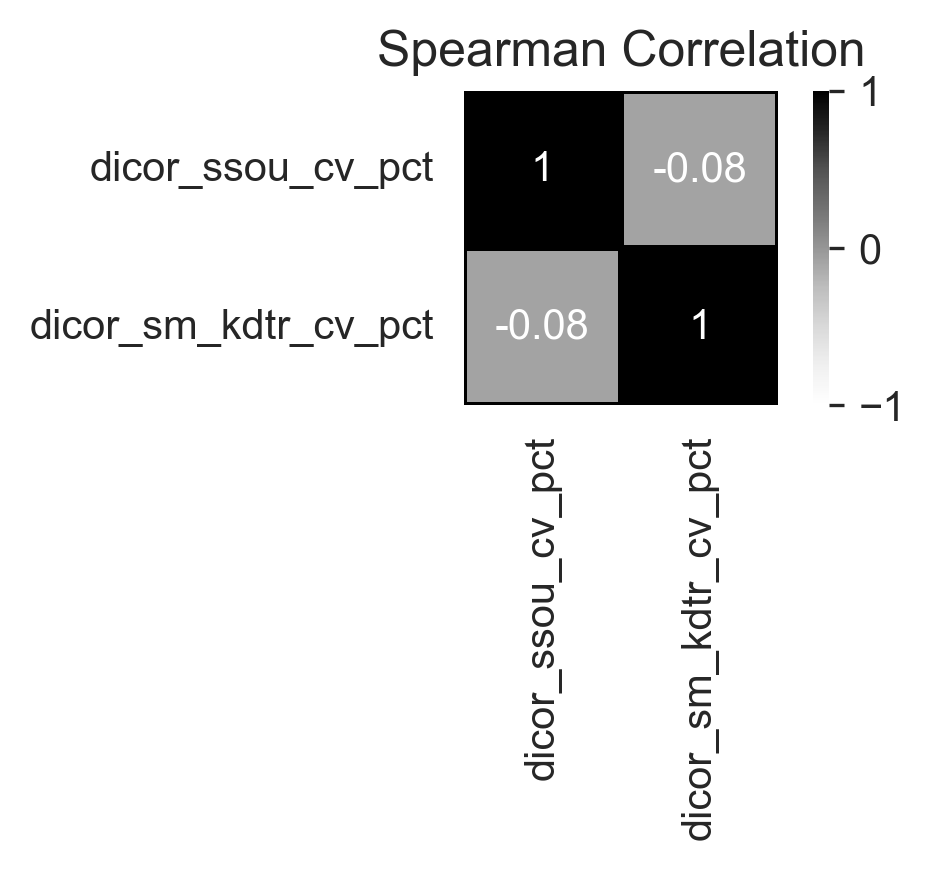

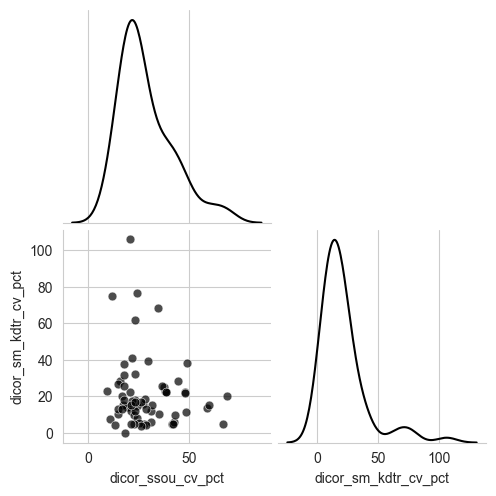

In [8]:
# ==========================================
# DICOR variability structure
# ==========================================

dicor_cluster_vars = [
    "dicor_ssou_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

cluster_df = df[dicor_cluster_vars].dropna().copy()

print("Cluster dataset shape:", cluster_df.shape)

# ==========================================
# Correlation matrix
# ==========================================

corr = cluster_df.corr(method="spearman")

display(corr)

# ==========================================
# Heatmap
# ==========================================

plt.figure(figsize=(4, 3), dpi=300)

sns.heatmap(
    corr,
    annot=True,
    cmap="Greys",
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=1,
    linecolor="black",
)

plt.title("Spearman Correlation")
plt.tight_layout()
plt.show()

# ==========================================
# Pairplot
# ==========================================

sns.pairplot(
    cluster_df,
    corner=True,
    diag_kind="kde",
    plot_kws={
        "color": "black",
        "alpha": 0.7,
        "s": 40,
    },
    diag_kws={
        "color": "black",
        "fill": False,
    }
)

plt.show()


dicor_ssou_cv_pct
n: 68
mean: 28.84
median: 24.27
std: 13.33
IQR: 17.12
skewness: 1.13
kurtosis: 0.85

Quantiles:
0.10    15.804182
0.25    19.865864
0.50    24.270209
0.75    36.983409
0.90    48.261052
Name: dicor_ssou_cv_pct, dtype: float64

dicor_sm_kdtr_cv_pct
n: 68
mean: 20.92
median: 15.51
std: 19.04
IQR: 13.35
skewness: 2.35
kurtosis: 6.25

Quantiles:
0.10     4.809983
0.25    10.109597
0.50    15.505850
0.75    23.458813
0.90    38.828315
Name: dicor_sm_kdtr_cv_pct, dtype: float64


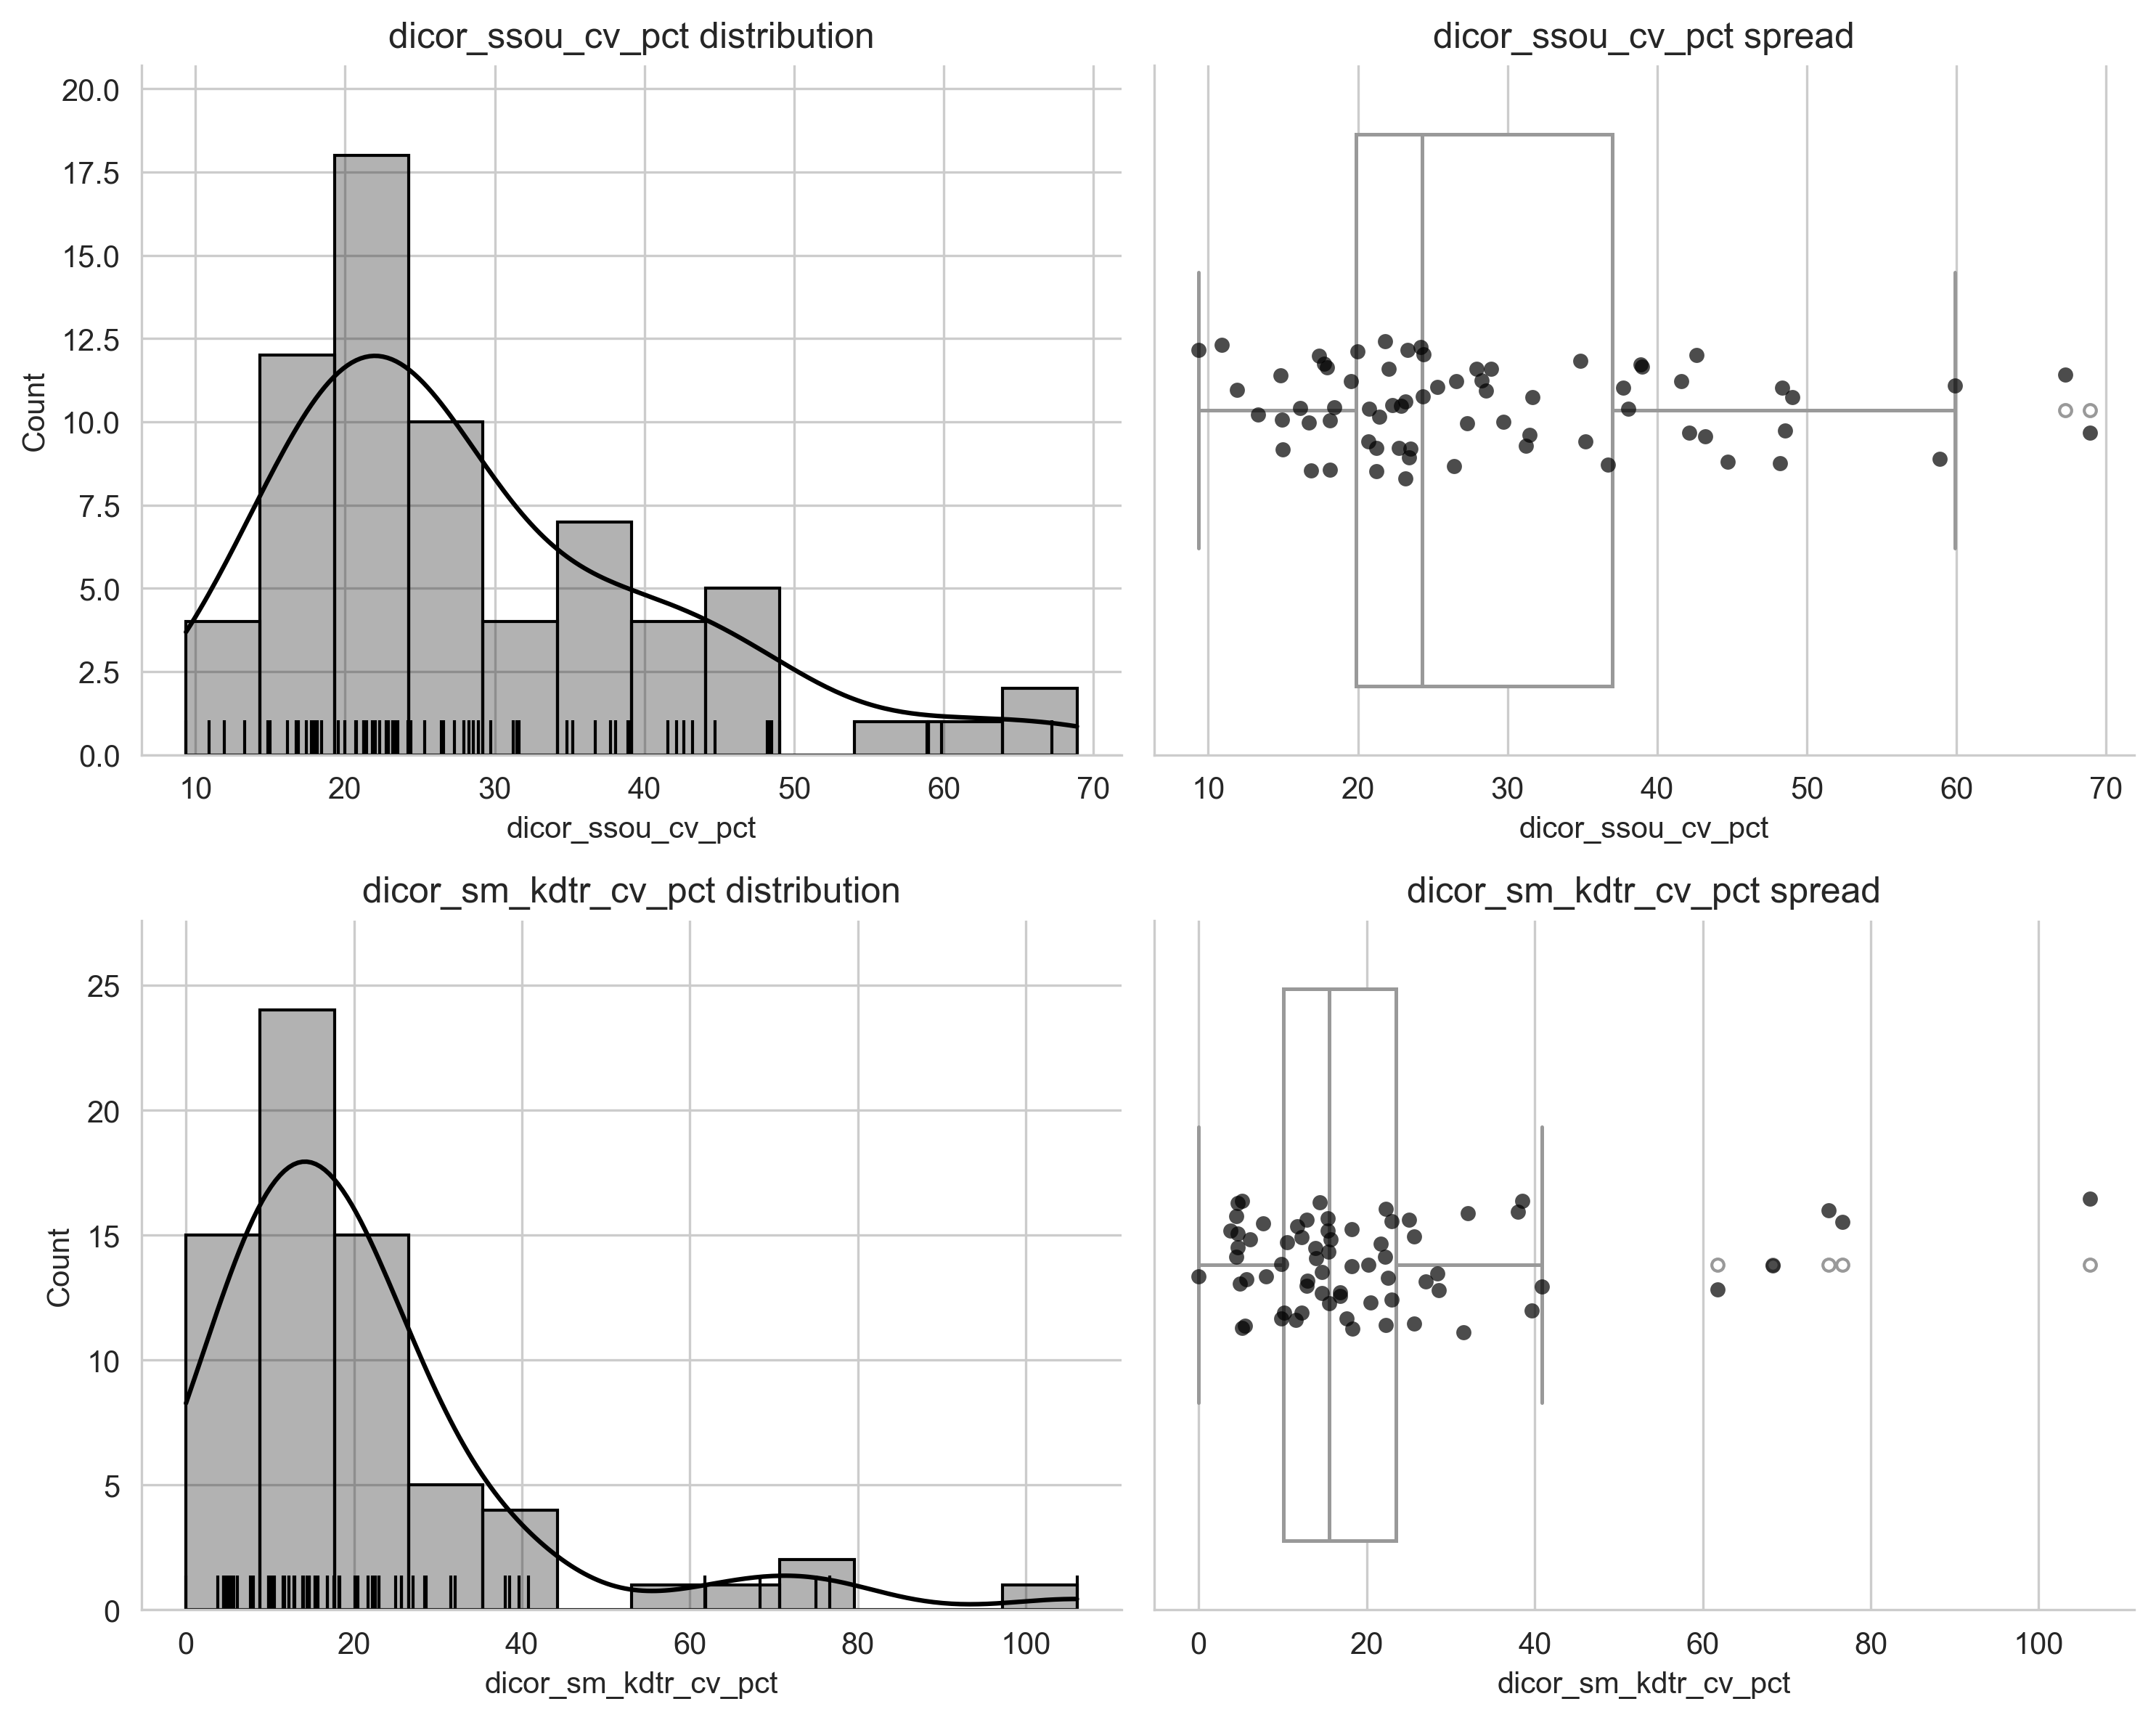

In [9]:
# ==========================================
# Distribution structure analysis
# ==========================================

from scipy.stats import skew, kurtosis

dicor_cluster_vars = [
    "dicor_ssou_cv_pct",
    "dicor_sm_kdtr_cv_pct",
]

fig, axes = plt.subplots(
    len(dicor_cluster_vars),
    2,
    figsize=(10, 8),
    dpi=300
)

for i, var in enumerate(dicor_cluster_vars):
    
    x = df[var].dropna()
    
    # --------------------------------------
    # Histogram + KDE
    # --------------------------------------
    
    sns.histplot(
        x,
        bins=12,
        kde=True,
        color="black",
        edgecolor="black",
        alpha=0.3,
        ax=axes[i, 0]
    )
    
    sns.rugplot(
        x=x,
        color="black",
        height=0.05,
        ax=axes[i, 0]
    )
    
    axes[i, 0].set_title(f"{var} distribution")
    
    # --------------------------------------
    # Boxplot
    # --------------------------------------
    
    sns.boxplot(
        x=x,
        color="white",
        linewidth=1.2,
        fliersize=4,
        ax=axes[i, 1]
    )
    
    sns.stripplot(
        x=x,
        color="black",
        size=5,
        alpha=0.7,
        ax=axes[i, 1]
    )
    
    axes[i, 1].set_title(f"{var} spread")
    
    # --------------------------------------
    # Stats
    # --------------------------------------
    
    print("\n" + "="*70)
    print(var)
    print("="*70)
    
    print("n:", len(x))
    print("mean:", round(x.mean(), 2))
    print("median:", round(x.median(), 2))
    print("std:", round(x.std(), 2))
    print("IQR:", round(x.quantile(0.75) - x.quantile(0.25), 2))
    print("skewness:", round(skew(x), 2))
    print("kurtosis:", round(kurtosis(x), 2))
    
    print("\nQuantiles:")
    print(x.quantile([0.1, 0.25, 0.5, 0.75, 0.9]))

# ------------------------------------------
# Q1 style
# ------------------------------------------

for ax_row in axes:
    for ax in ax_row:
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Distribution analysis demonstrated marked right-skewness and heavy-tailed variability distributions, particularly for dicor_sm_kdtr_cv_pct.

Visual inspection did not support the presence of clearly separated spherical or Gaussian-like clusters.

Due to the absence of visually distinct cluster boundaries and the presence of continuous heavy-tailed heterogeneity, conventional clustering approaches (e.g., KMeans) were considered potentially artificial and physiologically non-interpretable.

In [10]:
# ==========================================
# Extreme KDTR phenotype
# ==========================================

kdtr_var = "dicor_sm_kdtr_cv_pct"

# 85 percentile threshold
kdtr_threshold = df[kdtr_var].quantile(0.85)

print("KDTR 85 percentile threshold:", round(kdtr_threshold, 2))

# Phenotype
df["Extreme_KDTR_Phenotype"] = np.where(
    df[kdtr_var] >= kdtr_threshold,
    "Extreme-KDTR",
    "Non-Extreme"
)

# Counts
print("\nPhenotype counts:")
print(df["Extreme_KDTR_Phenotype"].value_counts())

# Summary stats
display(
    df.groupby("Extreme_KDTR_Phenotype")[kdtr_var]
    .describe()
)

# Save subset
extreme_kdtr_df = df[
    ~df[kdtr_var].isna()
].copy()

print("\nWorking cohort shape:", extreme_kdtr_df.shape)

KDTR 85 percentile threshold: 31.35

Phenotype counts:
Extreme_KDTR_Phenotype
Non-Extreme     142
Extreme-KDTR     11
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Extreme_KDTR_Phenotype,,,,,,,,
Extreme-KDTR,11.0,55.293054,24.031573,31.491833,38.231684,40.809916,71.658793,106.066017
Non-Extreme,57.0,14.286481,7.315235,0.000000,8.000000,14.380637,20.156360,28.571429



Working cohort shape: (68, 223)


Extreme_KDTR_Phenotype,Extreme-KDTR,Non-Extreme
Chord_Orientation,,
Oblique-Only,0,15
Transverse-Involved,11,72



Fisher exact test
Odds ratio: 0.0
p-value: 0.2062


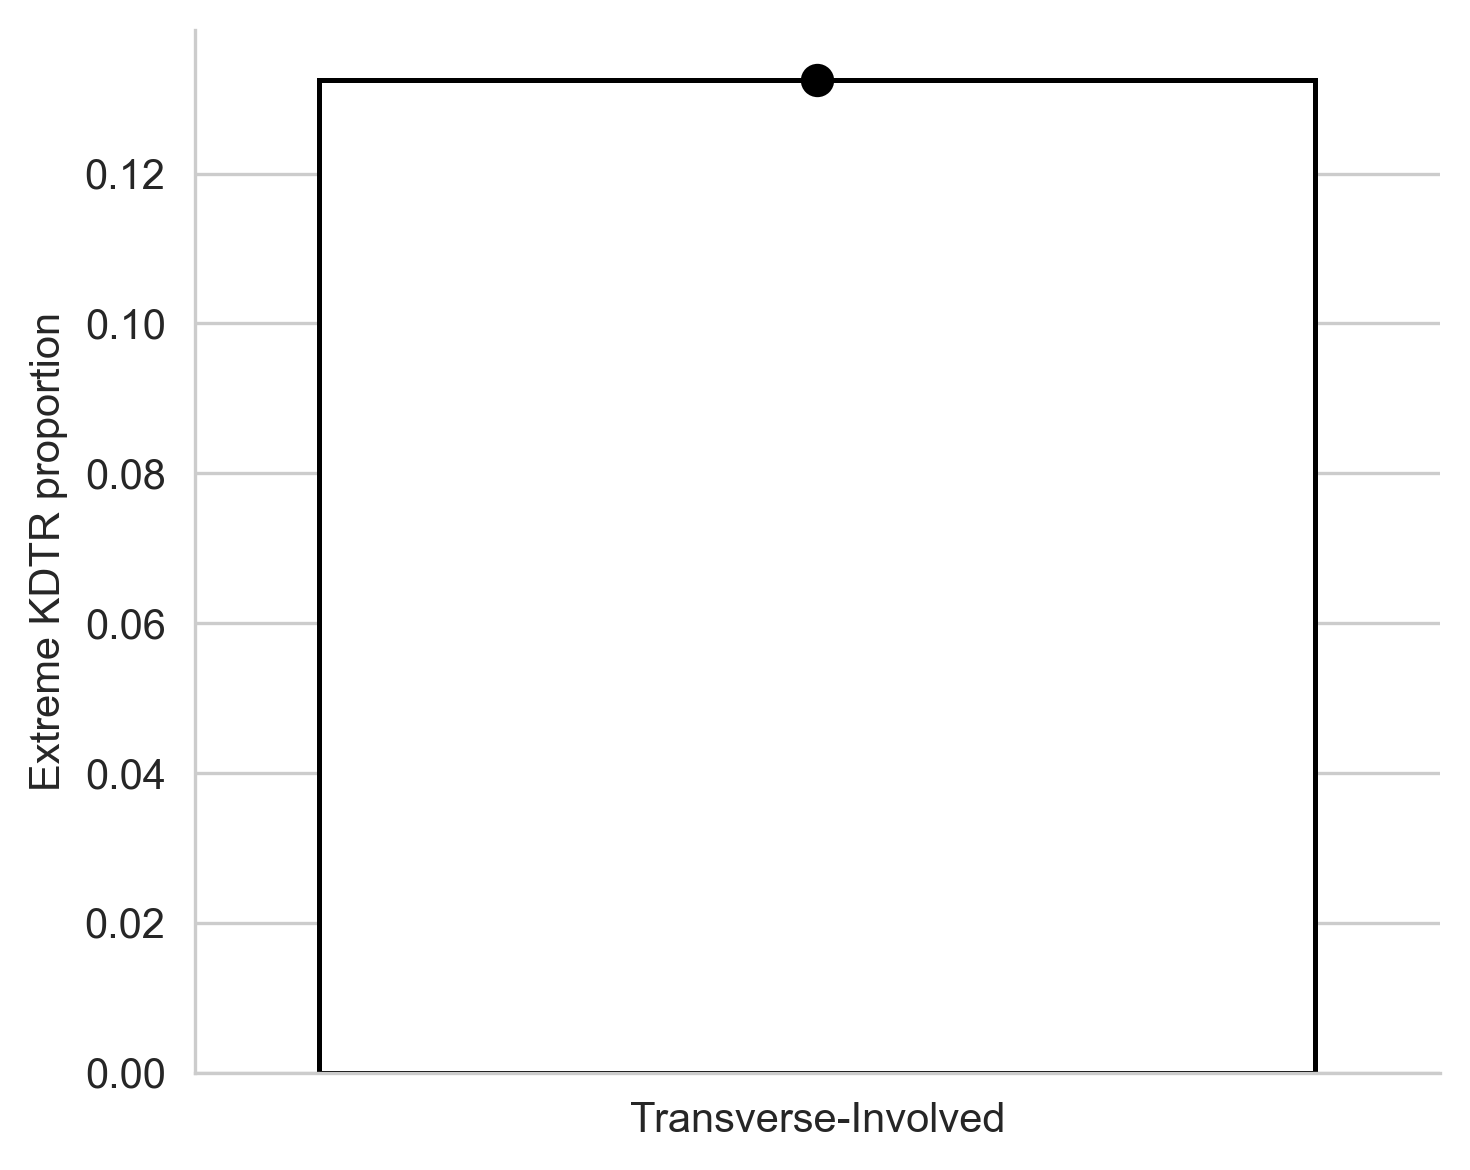

In [11]:
# ==========================================
# Extreme KDTR vs Chord Orientation
# ==========================================

from scipy.stats import fisher_exact

# Only classified orientation
orientation_df = df[
    df["Chord_Orientation"].isin([
        "Oblique-Only",
        "Transverse-Involved"
    ])
].copy()

# Contingency table
orientation_table = pd.crosstab(
    orientation_df["Chord_Orientation"],
    orientation_df["Extreme_KDTR_Phenotype"]
)

display(orientation_table)

# Fisher exact
odds_ratio, p_value = fisher_exact(orientation_table)

print("\nFisher exact test")
print("Odds ratio:", round(odds_ratio, 3))
print("p-value:", round(p_value, 4))

# ==========================================
# Visualization
# ==========================================

plot_df = (
    orientation_df
    .groupby("Chord_Orientation")["Extreme_KDTR_Phenotype"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

plot_df = plot_df[
    plot_df["Extreme_KDTR_Phenotype"] == "Extreme-KDTR"
]

plt.figure(figsize=(5, 4), dpi=300)

sns.barplot(
    data=plot_df,
    x="Chord_Orientation",
    y="proportion",
    color="white",
    edgecolor="black",
    linewidth=1.2
)

sns.stripplot(
    data=plot_df,
    x="Chord_Orientation",
    y="proportion",
    color="black",
    size=8
)

plt.ylabel("Extreme KDTR proportion")
plt.xlabel("")

ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

Extreme_KDTR_Phenotype,Extreme-KDTR,Non-Extreme
Chord_Spread_Class,,
Adjacent Regions,0,17
Distant Regions,11,61
Same Region,0,9


Extreme_KDTR_Phenotype,Extreme-KDTR,Non-Extreme
Chord_Spread_Class,,
Adjacent Regions,0.000000,1.000000
Distant Regions,0.152778,0.847222
Same Region,0.000000,1.000000


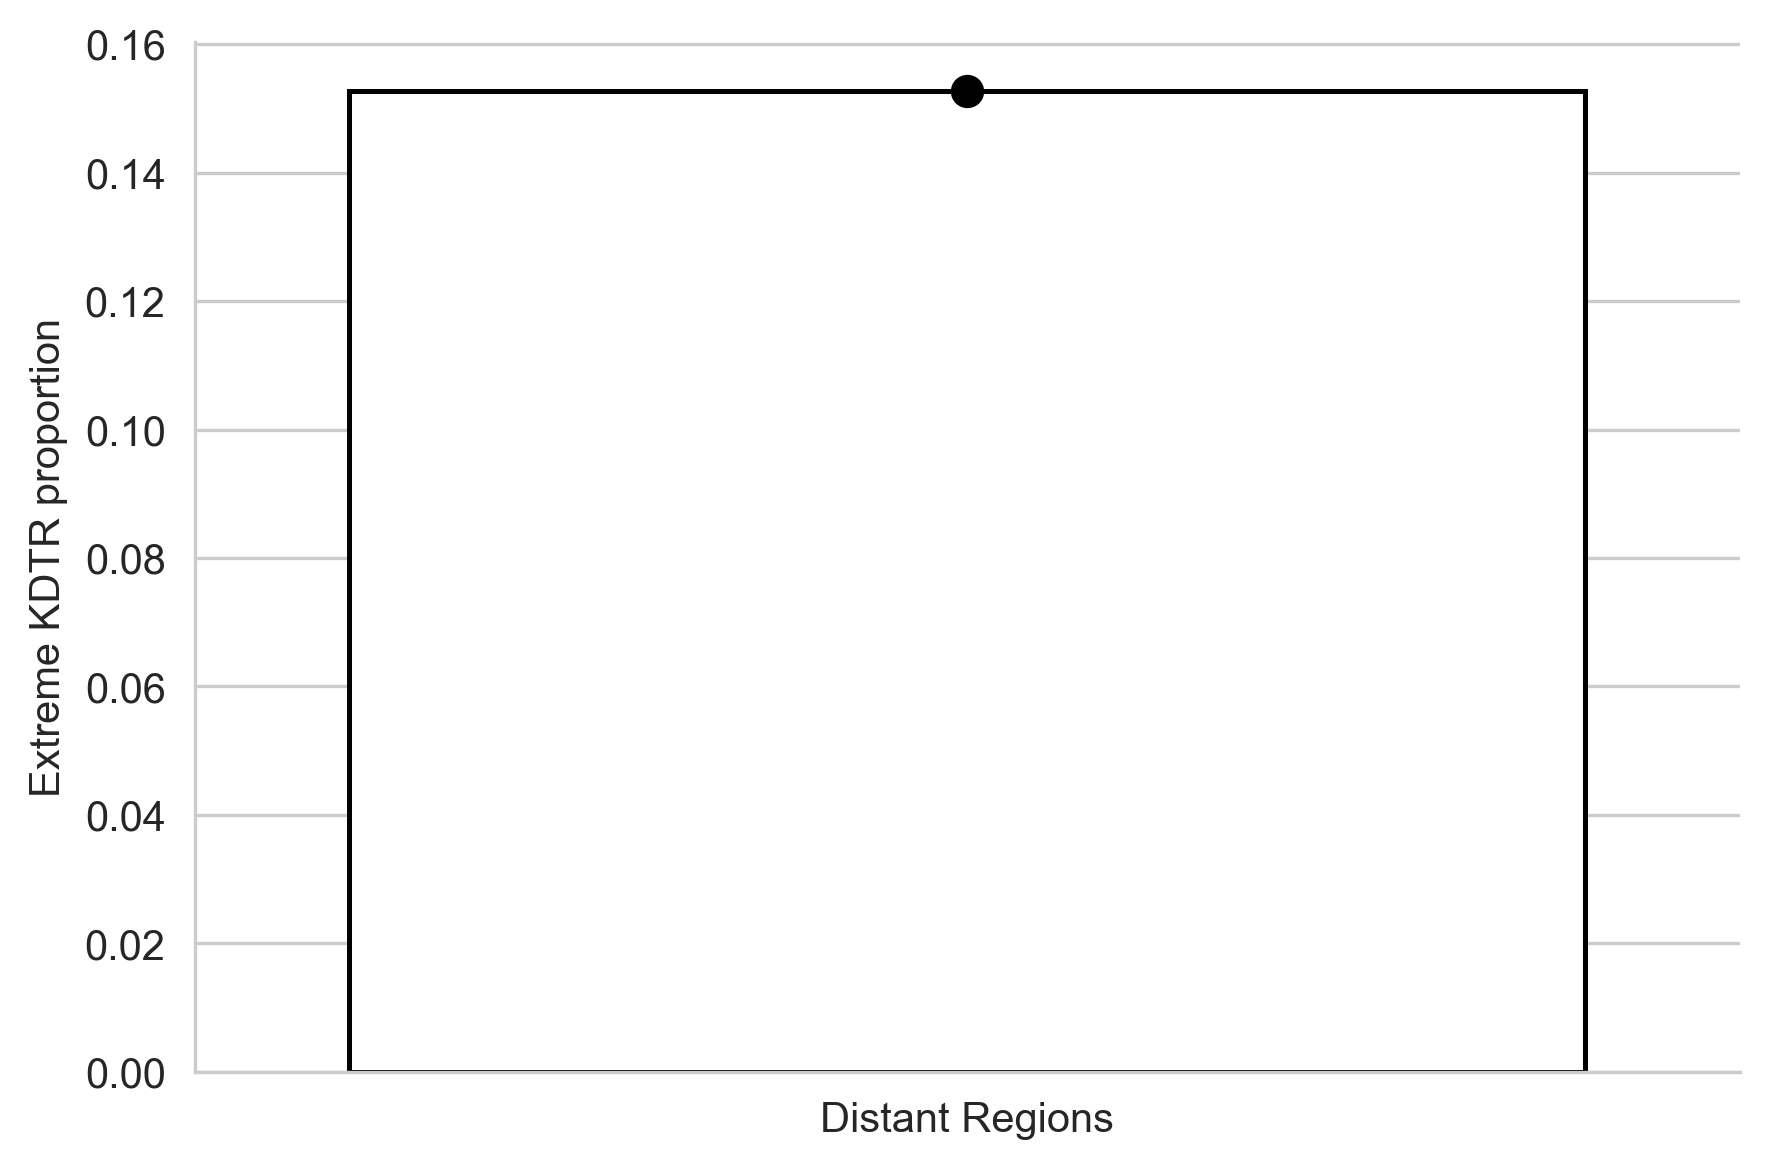

In [12]:
# ==========================================
# Extreme KDTR vs Spatial Spread
# ==========================================

spread_df = df[
    df["Chord_Spread_Class"].isin([
        "Same Region",
        "Adjacent Regions",
        "Distant Regions"
    ])
].copy()

# Contingency table
spread_table = pd.crosstab(
    spread_df["Chord_Spread_Class"],
    spread_df["Extreme_KDTR_Phenotype"]
)

display(spread_table)

# Row proportions
spread_prop = (
    spread_table.div(
        spread_table.sum(axis=1),
        axis=0
    )
)

display(spread_prop)

# ==========================================
# Visualization
# ==========================================

plot_df = (
    spread_df
    .groupby("Chord_Spread_Class")["Extreme_KDTR_Phenotype"]
    .value_counts(normalize=True)
    .rename("proportion")
    .reset_index()
)

plot_df = plot_df[
    plot_df["Extreme_KDTR_Phenotype"] == "Extreme-KDTR"
]

plt.figure(figsize=(6, 4), dpi=300)

sns.barplot(
    data=plot_df,
    x="Chord_Spread_Class",
    y="proportion",
    color="white",
    edgecolor="black",
    linewidth=1.2
)

sns.stripplot(
    data=plot_df,
    x="Chord_Spread_Class",
    y="proportion",
    color="black",
    size=8
)

plt.ylabel("Extreme KDTR proportion")
plt.xlabel("")

ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()